In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\kaggle_data\archive\olist_orders_dataset.csv")
items = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\kaggle_data\archive\olist_order_items_dataset.csv")
customers = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\kaggle_data\archive\olist_customers_dataset.csv")
products = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\kaggle_data\archive\olist_products_dataset.csv")
payments = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\kaggle_data\archive\olist_order_payments_dataset.csv")

print(orders.shape)
print(items.shape)
print(customers.shape)
print(products.shape)
print(payments.shape)


(99441, 8)
(112650, 7)
(99441, 5)
(32951, 9)
(103886, 5)


In [3]:
# orders data explore
print("First 5 rows: ")
print(orders.head())
print("shape: ")
print(orders.shape)
print(orders.columns.tolist())
print(orders.dtypes)
print(orders.isnull().sum())
print(orders['order_status'].value_counts())

First 5 rows: 
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00   

In [4]:
# items data explore 
display(items.head())
print(items.isnull().sum())
print(items['price'].describe())
print(items['freight_value'].describe)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64
<bound method NDFrame.describe of 0         13.29
1         19.93
2         17.87
3         12.79
4         18.14
          ...  
112645    43.41
112646    36.53
112647    16.95
112648     8.72
112649    12.79
Name: freight_value, Length: 112650, dtype: float64>


In [5]:
# data cleaning
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors = 'coerce')

# only delivered orders 
print(f"before filter : {orders.shape[0]} row")
orders = orders[orders['order_status'] =='delivered'].copy()
print(f"after filter : {orders.shape[0]} rows")

# Merge all tables 
df = orders.merge(items, on = 'order_id', how = 'left')
df = df.merge(customers,on = 'customer_id',how = 'left')
df = df.merge(products, on = 'product_id', how = 'left')
df = df.merge(payments, on = 'order_id', how = 'left')
print(f"After merge shape : {df.shape}")

#drop the duplicate rows
before = df.shape[0]
df.drop_duplicates(inplace = True)
print(f"duplicates removed : {before - df.shape[0]}")

# New columns creation 
df['month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp()
df['year'] = df['order_purchase_timestamp'].dt.year
df['quarter'] = df['order_purchase_timestamp'].dt.quarter
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
df['total_price'] = df['price'] + df['freight_value']
print(df[['order_id','price','total_price','month','year']].head())

before filter : 99441 row
after filter : 96478 rows
After merge shape : (115038, 30)
duplicates removed : 0
                           order_id   price  total_price      month  year
0  e481f51cbdc54678b7cc49136f2d6af7   29.99        38.71 2017-10-01  2017
1  e481f51cbdc54678b7cc49136f2d6af7   29.99        38.71 2017-10-01  2017
2  e481f51cbdc54678b7cc49136f2d6af7   29.99        38.71 2017-10-01  2017
3  53cdb2fc8bc7dce0b6741e2150273451  118.70       141.46 2018-07-01  2018
4  47770eb9100c2d0c44946d9cf07ec65d  159.90       179.12 2018-08-01  2018


In [6]:
total_revenue = df['price'].sum()
total_orders = df['order_id'].nunique()
avg_order_val = df['price'].mean()
total_customers = df['customer_id'].nunique()
total_cities = df['customer_city'].nunique()

print("=" * 40)
print("KEY BUSINESS MATRICES")
print("=" * 40)
print(f"Total Revenue : R$ {total_revenue :,.2f}")
print(f"Total orders : {total_revenue :,}")
print(f"avg order Value : R$ {avg_order_val:.2f}")
print(f"Unique customers : {total_customers :,}")
print(f"cities covered : {total_cities :,}")

KEY BUSINESS MATRICES
Total Revenue : R$ 13,813,963.68
Total orders : 13,813,963.68
avg order Value : R$ 120.08
Unique customers : 96,478
cities covered : 4,085


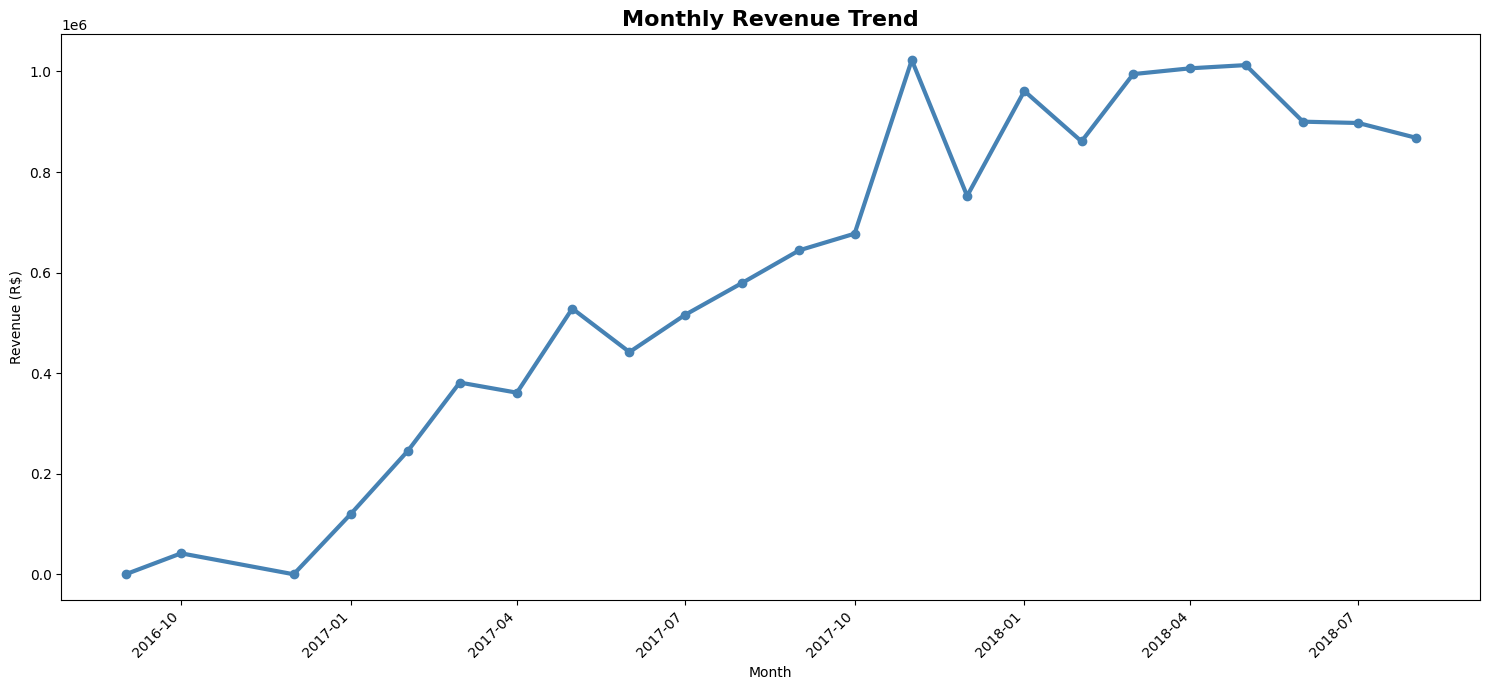

In [7]:
monthly_rev = df.groupby('month')['price'].sum().reset_index()
monthly_rev.columns = ['month', 'revenue']
monthly_rev = monthly_rev.sort_values('month').reset_index(drop=True)

plt.figure(figsize=(15,7))
plt.plot(monthly_rev['month'], monthly_rev['revenue'],
         marker='o', linewidth=3, color='steelblue', markersize=6)
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.show()

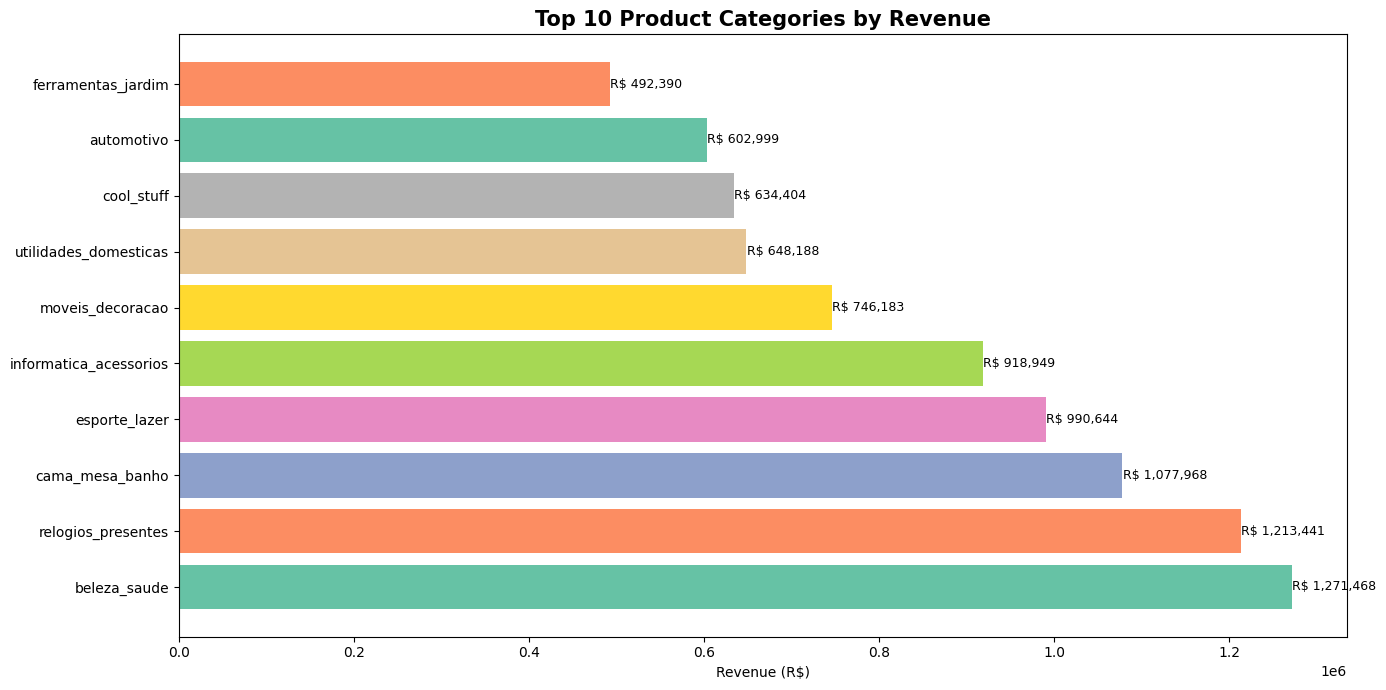

In [8]:
# Top 10 Categories(Bar chart)
top_cat = (df.groupby('product_category_name')['price'].sum().nlargest(10).reset_index().rename(columns={'price':'revenue'}))
plt.figure(figsize=(14,7))
bars = plt.barh(top_cat['product_category_name'],top_cat['revenue'],color=sns.color_palette("Set2",10))

# value label 
for bar, val in zip(bars,top_cat['revenue']):
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,f'R${val : ,.0f}',va='center',fontsize = 9)

plt.title('Top 10 Product Categories by Revenue', fontsize=15,fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14632\1201973096.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_cities,x='revenue',y='customer_city',palette='Blues_r')


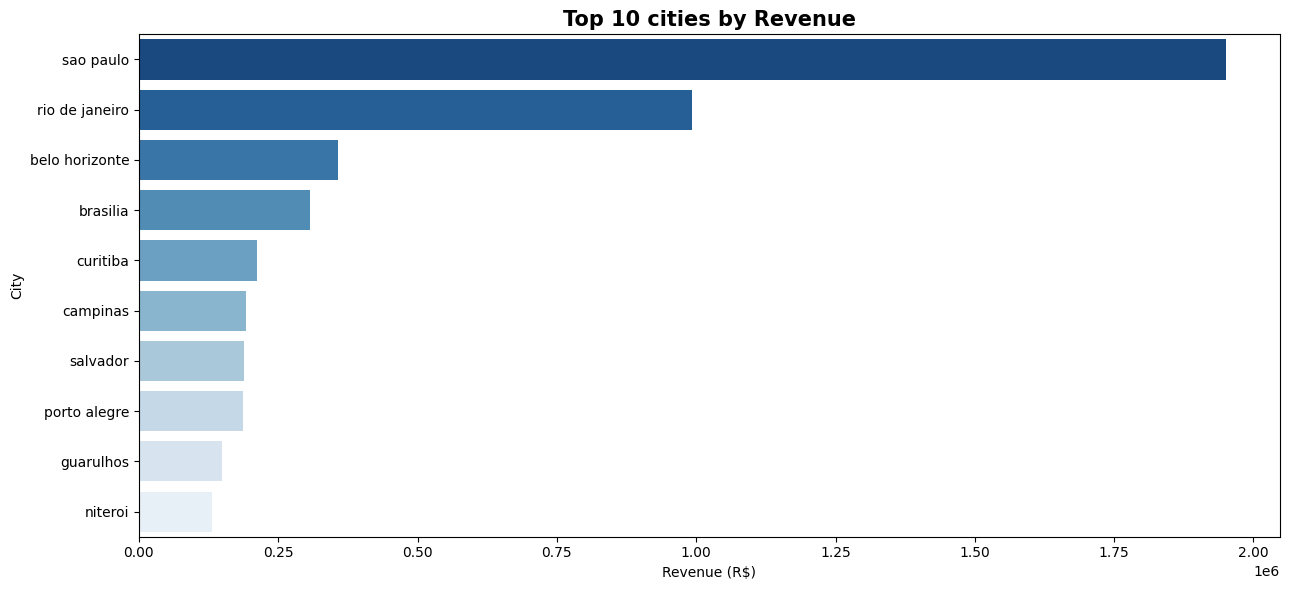

In [9]:
# top 10 cities by revenue 
top_cities = (df.groupby('customer_city')['price'].sum().nlargest(10).reset_index().rename(columns={'price':'revenue'}))
plt.figure(figsize=(13,6))
sns.barplot(data=top_cities,x='revenue',y='customer_city',palette='Blues_r')
plt.title('Top 10 cities by Revenue',fontsize=15,fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.ylabel('City')
plt.tight_layout()
plt.show()

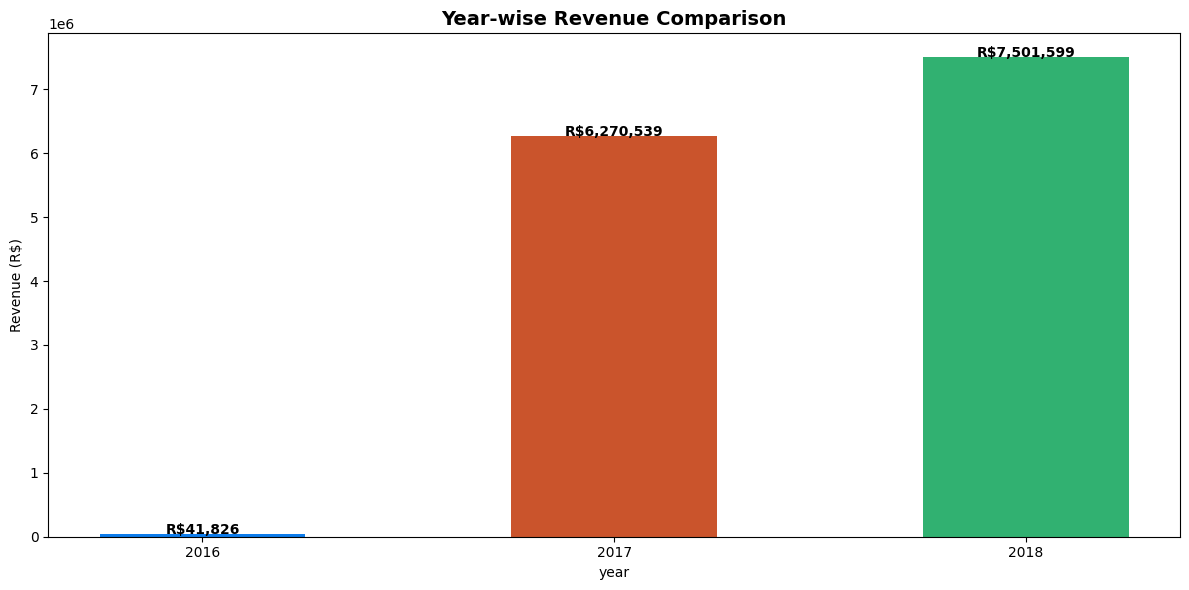

In [10]:
# Year-wise Sales(Bar chart)
yearly = (df.groupby('year')['price'].sum().reset_index().rename(columns={'price':'revenue'}))
plt.figure(figsize=(12,6))
bars = plt.bar(yearly['year'].astype(str),yearly['revenue'],color=['#0D7CEB','#CA542C',"#31B171"],width=0.5)
for bar,val in zip(bars,yearly['revenue']):
    plt.text(bar.get_x() + bar.get_width()/2,bar.get_height()+1000,f'R${val:,.0f}',ha='center',fontsize=10,fontweight='bold')
plt.title('Year-wise Revenue Comparison',fontsize=14,fontweight='bold')
plt.xlabel('year')
plt.ylabel('Revenue (R$)')
plt.tight_layout()
plt.show()

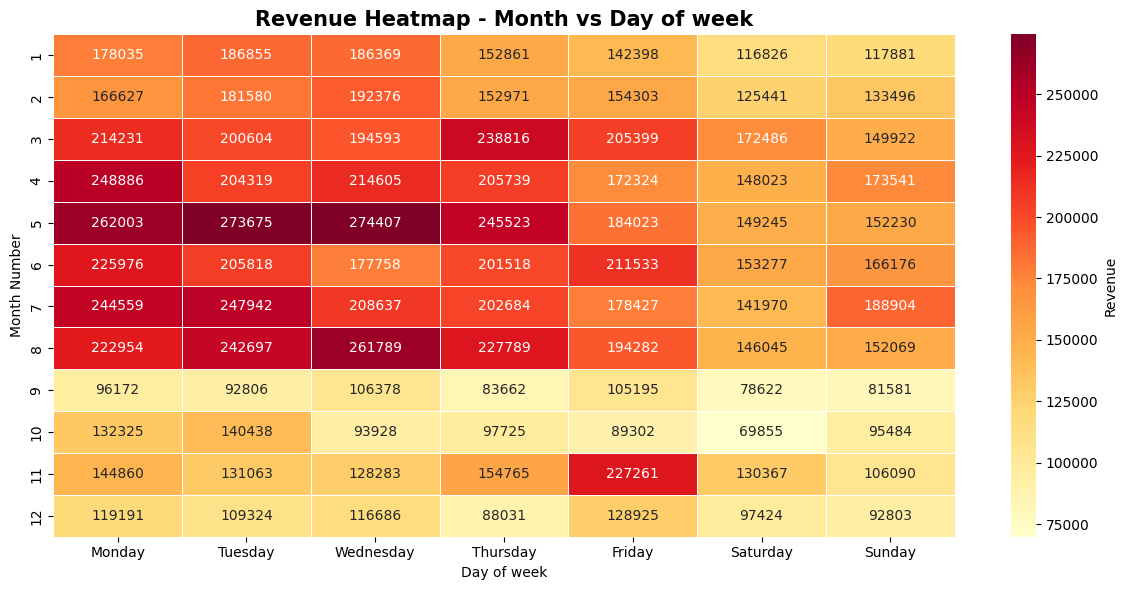

In [11]:
# Heatmap (month vs day)
df['month_num'] = df['order_purchase_timestamp'].dt.month
df['day_num'] = df['order_purchase_timestamp'].dt.dayofweek
heatmap_data = (df.groupby(['month_num','day_of_week'])['price'].sum().unstack())
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(columns=day_order)

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data,cmap='YlOrRd',fmt='.0f',annot=True,linewidths = 0.5,cbar_kws={'label':'Revenue'})
plt.title('Revenue Heatmap - Month vs Day of week',fontsize = 15,fontweight = 'bold')
plt.xlabel('Day of week')
plt.ylabel('Month Number')
plt.tight_layout()
plt.show()

In [12]:
# save cleaned data for SQL 
cols_to_save = ['order_id','customer_id','customer_city','customer_state','product_id','product_category_name','price',
                'freight_value','total_price','payments_value','payment_type','month','year','quarter','day_of_week',
                'order_purchase_timestamp']

# only that columns who present in df
cols_available = [c for c in cols_to_save if c in df.columns]
df_clean = df[cols_available].copy()
df_clean.to_csv(r'C:\Users\Admin\Onedrive\Desktop\kaggle_data\olist_cleaned_data.csv',index=False)
print(f"shape :{df_clean.shape}")
print(f"Columns :{df_clean.columns.tolist()}")

shape :(115038, 15)
Columns :['order_id', 'customer_id', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'price', 'freight_value', 'total_price', 'payment_type', 'month', 'year', 'quarter', 'day_of_week', 'order_purchase_timestamp']


In [13]:
# Monthly Sales for Forecasting 
monthly_forecast = (df.groupby('month')['price'].sum().reset_index())
monthly_forecast.columns = ['ds','y']
monthly_forecast['ds'] = pd.to_datetime(monthly_forecast['ds'])
monthly_forecast = monthly_forecast.sort_values('ds').reset_index(drop= True)
print("Monthly data for forecasting : ")
print(f"\nTotal months available : {len(monthly_forecast)}")

Monthly data for forecasting : 

Total months available : 23


In [14]:
# Prophet Forecasting
from prophet import Prophet 
model = Prophet(yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                seasonality_mode='multiplicative',changepoint_prior_scale=0.05)
model.fit(monthly_forecast)
print("Model trained!")

#6 months Future
future = model.make_future_dataframe(periods=6,freq='MS')
forecast = model.predict(future)
display(forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(8))

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
20:00:28 - cmdstanpy - INFO - Chain [1] start processing
20:01:39 - cmdstanpy - INFO - Chain [1] done processing


Model trained!


,ds,yhat,yhat_lower,yhat_upper
21,2018-07-01,8.974857e+05,8.974857e+05,8.974857e+05
22,2018-08-01,8.683330e+05,8.683330e+05,8.683330e+05
23,2018-09-01,3.188781e+06,3.187989e+06,3.189550e+06
24,2018-10-01,1.476480e+06,1.475294e+06,1.477571e+06
25,2018-11-01,-1.534126e+06,-1.536223e+06,-1.531852e+06
26,2018-12-01,2.669722e+06,2.663567e+06,2.675485e+06
27,2019-01-01,2.459848e+06,2.452104e+06,2.467213e+06
28,2019-02-01,1.501005e+06,1.495149e+06,1.506705e+06


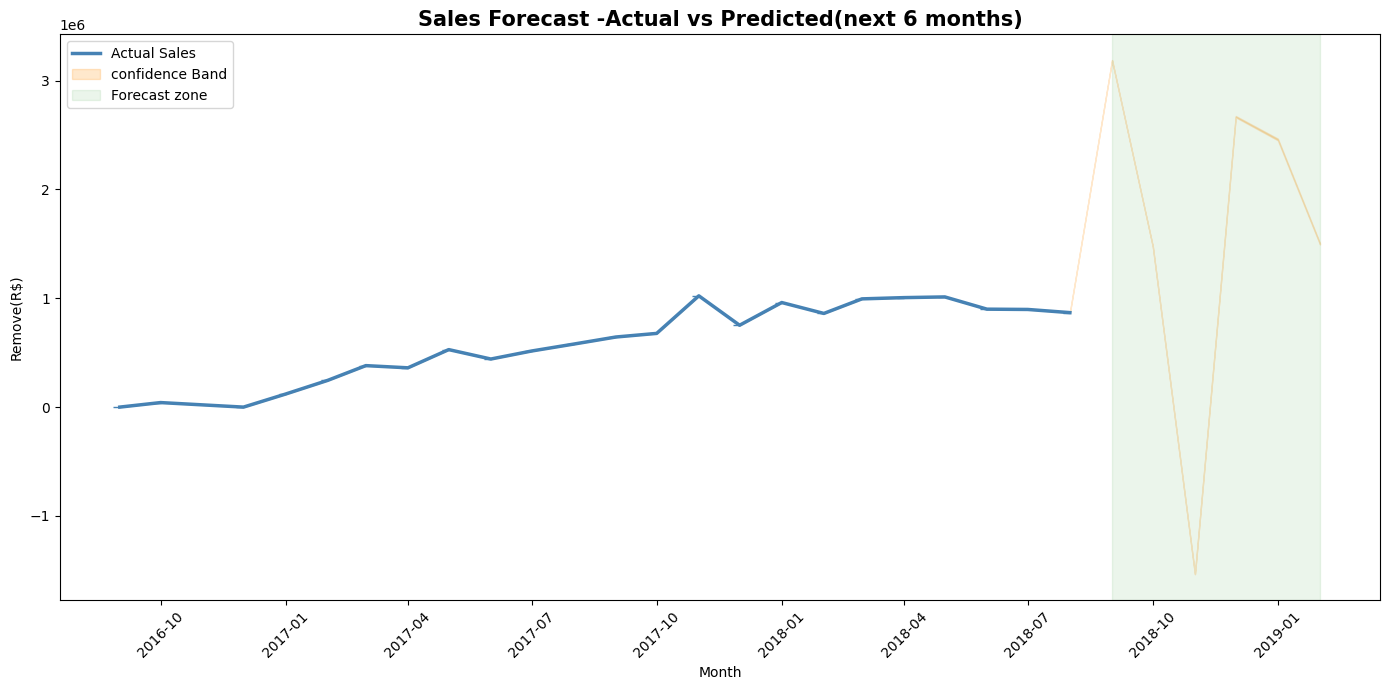

In [15]:
# forecast Plot (actual vs predicted)
result = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
result.columns = ['Month','Pridicted_Sales','Lower_Bound','Upper_Bound']

actual = monthly_forecast.rename(columns={'ds':'Month','y':'Actual_Sales'})
final = pd.merge(result,actual,on='Month',how='left')

plt.figure(figsize=(14,7))
#Actual Line
plt.plot(final['Month'],final['Actual_Sales'],label='Actual Sales',color='steelblue',
         linewidth=2.5,marker=0,markersize=5)
# Predicted line
plt.fill_between(final['Month'],
                 final['Lower_Bound'],
                 final['Upper_Bound'],
                 alpha=0.2,color='darkorange',label='confidence Band')

#Future Region highlight
future_mask = final['Actual_Sales'].isna()
plt.axvspan(final[future_mask]['Month'].iloc[0],final['Month'].iloc[-1],alpha=0.08,color='green',label='Forecast zone')
plt.title('Sales Forecast -Actual vs Predicted(next 6 months)',fontsize=15,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Remove(R$)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Save forecast.csv
for col in ['Month','Lower_Bound','Upper_Bound']:
    final[col] = final[col].round(2)

final.to_csv(r'C:\Users\Admin\Onedrive\Desktop\kaggle_data\olist_forecast_data.csv',index=False)
display(final.tail(8))

C:\Users\Admin\AppData\Local\Temp\ipykernel_14632\2020770377.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  final[col] = final[col].round(2)


,Month,Pridicted_Sales,Lower_Bound,Upper_Bound,Actual_Sales
21,2018-07-01,8.974857e+05,897485.70,897485.70,897484.91
22,2018-08-01,8.683330e+05,868333.01,868333.01,868332.81
23,2018-09-01,3.188781e+06,3187989.30,3189549.81,NaN
24,2018-10-01,1.476480e+06,1475293.52,1477571.25,NaN
25,2018-11-01,-1.534126e+06,-1536222.67,-1531852.20,NaN
26,2018-12-01,2.669722e+06,2663567.22,2675484.91,NaN
27,2019-01-01,2.459848e+06,2452104.40,2467213.32,NaN
28,2019-02-01,1.501005e+06,1495149.39,1506704.89,NaN


In [17]:
%pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# import data from python to MySQL
import pandas as pd
import mysql.connector
from mysql.connector import Error

df = pd.read_csv(r'C:\Users\Admin\Onedrive\Desktop\kaggle_data\olist_cleaned_data.csv')
# For Timestamp column fixing
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'],errors='coerce')
df['order_purchase_timestamp'] = df['order_purchase_timestamp'].dt.strftime('%Y-%m-%d %H:%M:%S')

# replacing Nan To Null For SQL
df = df.where(pd.notnull(df),None)
print(f'Total rows to insert: {len(df)}')
print(f"Columns : {df.columns.tolist()}")

Total rows to insert: 115038
Columns : ['order_id', 'customer_id', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'price', 'freight_value', 'total_price', 'payment_type', 'month', 'year', 'quarter', 'day_of_week', 'order_purchase_timestamp']


In [22]:

# MySQL connection + data insert


import pandas as pd
import mysql.connector
from mysql.connector import Error

df = pd.read_csv(r'C:\Users\Admin\Onedrive\Desktop\kaggle_data\olist_cleaned_data.csv')

# Timestamp fix
if 'order_purchase_timestamp' in df.columns:
    df['order_purchase_timestamp'] = pd.to_datetime(
        df['order_purchase_timestamp'], errors='coerce'
    ).dt.strftime('%Y-%m-%d %H:%M:%S')

# NaN → None
df = df.where(pd.notnull(df), None)

cols_to_use = [
    'order_id', 'customer_id', 'customer_city', 'customer_state',
    'product_id', 'product_category_name',
    'price', 'freight_value', 'total_price',
    'payment_value', 'payment_type',
    'month', 'year', 'quarter', 'day_of_week',
    'order_purchase_timestamp'
]


cols_final = [c for c in cols_to_use if c in df.columns]
print(f"Columns being inserted: {cols_final}")
print(f"Total columns: {len(cols_final)}")

try:
    conn = mysql.connector.connect(
        host='localhost',
        user='root',
        password='MySQL$onu@1234',  # ← apna password daalo
        database='ecommerce_db'
    )

    if conn.is_connected():
        print("MySQL se connected!")
        cursor = conn.cursor()

        # Table clear karo
        cursor.execute("TRUNCATE TABLE sales")
        print("Table cleared!")

        #  Dynamic insert query — columns aur %s automatically match honge
        col_names   = ', '.join(cols_final)
        placeholders = ', '.join(['%s'] * len(cols_final))
        insert_query = f"INSERT INTO sales ({col_names}) VALUES ({placeholders})"

        print(f"\nInsert query preview:")
        print(f"INSERT INTO sales ({col_names}) VALUES (...)")
        print(f"Placeholders count: {len(cols_final)}")

        # Rows prepare karo
        rows = [tuple(row) for row in df[cols_final].itertuples(index=False)]
        print(f"Total rows to insert: {len(rows)}")

        # Batch insert
        batch_size = 1000
        for i in range(0, len(rows), batch_size):
            batch = rows[i:i + batch_size]
            cursor.executemany(insert_query, batch)
            conn.commit()
            print(f"  Inserted: {min(i+batch_size, len(rows))}/{len(rows)}")

        print(f"\n Data inserted successfully!")

except Error as e:
    print(f" Error: {e}")

finally:
    if conn.is_connected():
        cursor.close()
        conn.close()
        print(" MySQL connection closed.")

Columns being inserted: ['order_id', 'customer_id', 'customer_city', 'customer_state', 'product_id', 'product_category_name', 'price', 'freight_value', 'total_price', 'payment_type', 'month', 'year', 'quarter', 'day_of_week', 'order_purchase_timestamp']
Total columns: 15
MySQL se connected!
Table cleared!

Insert query preview:
INSERT INTO sales (order_id, customer_id, customer_city, customer_state, product_id, product_category_name, price, freight_value, total_price, payment_type, month, year, quarter, day_of_week, order_purchase_timestamp) VALUES (...)
Placeholders count: 15
Total rows to insert: 115038
  Inserted: 1000/115038
  Inserted: 2000/115038
  Inserted: 3000/115038
  Inserted: 4000/115038
  Inserted: 5000/115038
  Inserted: 6000/115038
  Inserted: 7000/115038
  Inserted: 8000/115038
  Inserted: 9000/115038
  Inserted: 10000/115038
  Inserted: 11000/115038
  Inserted: 12000/115038
  Inserted: 13000/115038
  Inserted: 14000/115038
  Inserted: 15000/115038
  Inserted: 16000/115

In [20]:
conn = mysql.connector.connect(
        host = 'localhost',
        user = 'root',
        password='MySQL$onu@1234',
        database = 'ecommerce_db')
df_check = pd.read_sql("SELECT * FROM sales LIMIT 5",conn)
print(f"Total row check: ")
df_count = pd.read_sql("SELECT COUNT(*) as total FROM sales",conn)
print(df_count)

Total row check: 
    total
0  115038


C:\Users\Admin\AppData\Local\Temp\ipykernel_14632\128752422.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_check = pd.read_sql("SELECT * FROM sales LIMIT 5",conn)
C:\Users\Admin\AppData\Local\Temp\ipykernel_14632\128752422.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_count = pd.read_sql("SELECT COUNT(*) as total FROM sales",conn)
